# Peptide → protein summarization

DDA search engines often report **peptide / PSM-level** intensities, but the downstream DE machinery works on **protein-level** matrices. `ov.protein.summarize` collapses a peptide-level `AnnData` to protein level, dispatching to the canonical algorithms from `pydeqms` (DEqMS) and `pymsstats` (MSstats):

| `method` | Algorithm | Backend |
|---|---|---|
| `median` | per-protein median across peptides | `pydeqms` |
| `median_sweeping` | TMT median sweeping | `pydeqms` |
| `medpolish` | Tukey median polish | `pydeqms` |
| `tmp` | MSstats Tukey-median-polish | `pymsstats` |
| `linear` | MSstats linear-model summarization | `pymsstats` |

In [1]:
import omicverse as ov
import numpy as np

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. A peptide-level dataset

`simulate_lfq(peptide_level=True)` returns an `AnnData` of samples × **peptides** with a `var['Protein']` column mapping each peptide to its parent protein. Each protein gets a random number of peptides (1–12 here), as in real DDA data. For real files this column comes from the search engine (`adata.var['Protein_IDs']` after `read_maxquant`).

In [2]:
pep = ov.protein.simulate_lfq(n_proteins=800, n_peptides_per_protein=12,
                              peptide_level=True, seed=0)
print(pep)
print('peptides:', pep.n_vars, '| parent proteins:', pep.var['Protein'].nunique())

AnnData object with n_obs × n_vars = 12 × 5129
    obs: 'group'
    var: 'Protein', 'is_de_true'
    uns: 'source'
peptides: 5129 | parent proteins: 800


## 2. Summarize to protein level

Each `method` returns a new protein-level `AnnData` (`obs` carried over, `var` = unique proteins).

In [3]:
for method in ['median', 'median_sweeping', 'medpolish', 'tmp', 'linear']:
    prot = ov.protein.summarize(pep, protein_col='Protein', method=method)
    print(f'{method:16s} -> {prot.shape}')

median           -> (12, 800)


median_sweeping  -> (12, 800)


medpolish        -> (12, 800)


tmp              -> (12, 800)


linear           -> (12, 800)


`medpolish` (Tukey median polish) is the most robust default — it down-weights outlier peptides. We use it for the rest of the workflow.

In [4]:
prot = ov.protein.summarize(pep, protein_col='Protein', method='medpolish')
prot

AnnData object with n_obs × n_vars = 12 × 800
    obs: 'group'
    uns: 'protein_summarize', 'source'

## 3. Differential expression on the summarized matrix

Once collapsed to protein level the object flows into the standard `ov.protein` pipeline. The peptide count per protein is recovered for DEqMS by counting peptides per parent protein.

In [5]:
pep_counts = pep.var['Protein'].value_counts()
prot.var['peptides'] = prot.var_names.map(pep_counts).fillna(1).astype(int)

res = ov.protein.de(prot, group='group', method='deqms', count_var='peptides')
res.head()

,gene,logFC,AveExpr,count,t,P.Value,adj.P.Val
0,prot_0586,-1.337915,0.061810,10.0,-11.706271,1.371031e-10,1.096825e-07
1,prot_0283,-1.245966,-0.036080,12.0,-10.737775,6.433145e-10,2.573258e-07
2,prot_0601,-1.168973,-0.034486,10.0,-10.281457,1.380058e-09,2.612740e-07
3,prot_0307,-1.041739,0.014209,12.0,-10.196893,1.593834e-09,2.612740e-07
4,prot_0784,-1.061566,0.079700,12.0,-10.182699,1.632963e-09,2.612740e-07


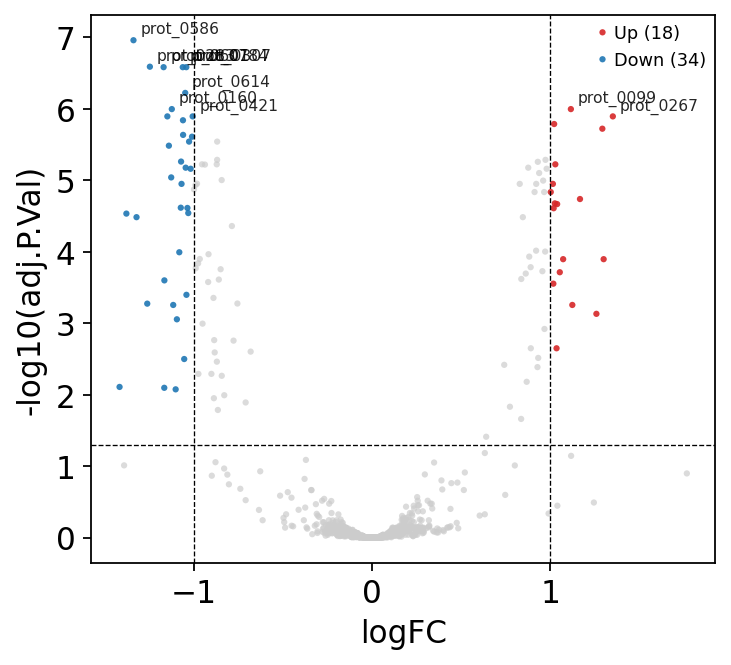

In [6]:
import matplotlib.pyplot as plt
ov.protein.volcano(res, fc_col='logFC', p_col='adj.P.Val')
plt.show()

## Summary

`summarize` is the bridge between peptide-level search-engine output and the protein-level DE workflow. After summarization the object is identical in shape to one produced by a protein-level reader, so every downstream `ov.protein` function applies unchanged. See [the bulk intro tutorial](t_protein_01_intro.ipynb) for the full QC → impute → DE pipeline.